# Fase 7 - Comparacao Fatal vs. Nao-Fatal

**Pergunta (sugestao do professor):** os contextos de alto lift sao especificos de acidentes *Fatais* ou aparecem tambem nos *Ferido* (nao-fatais)?

Este notebook **nao altera** a logica consolidada em `src/`. Ele apenas **reaproveita** `src/mining.py`, chamando `gerar_regras_contexto_para_fatal(..., consequente=desfecho_Ferido)` para minerar regras do desfecho nao-fatal e comparar com as regras fatais.

Como o desfecho e binario entre ocorrencias com vitimas (`Fatal` + `Ferido` = 100%), para um mesmo contexto vale `conf_Ferido = 1 - conf_Fatal`. Assim, contextos com lift alto para Fatal tendem a ter **lift < 1** para Ferido, confirmando que sao especificos da fatalidade.

In [1]:
import sys
import shutil
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import (
    ITEM_ALVO_FATAL,
    ITEM_ALVO_FERIDO,
    MIN_SUPPORT,
    MIN_COUNT_ABS,
    PROCESSED_DIR,
    FIGURAS_DIR,
    TABELAS_DIR,
)
from src.mining import (
    extrair_itemsets_e_regras,
    gerar_regras_contexto_para_fatal,
    minerar_regras_fatais,
    podar_regras_nao_minimais,
    adicionar_colunas_legiveis,
)

plt.rcParams["figure.figsize"] = (11, 6)
sns.set_style("whitegrid")

POSTER_FIG = ROOT / "relatorios" / "poster" / "figuras"
POSTER_TAB = ROOT / "relatorios" / "poster" / "tabelas"
POSTER_FIG.mkdir(parents=True, exist_ok=True)
POSTER_TAB.mkdir(parents=True, exist_ok=True)

COR_FATAL = "#c0392b"
COR_FERIDO = "#2980b9"

## 1. Dados e prevalencias

In [2]:
df = pd.read_pickle(PROCESSED_DIR / "transacional.pkl")
df_meta = pd.read_pickle(PROCESSED_DIR / "transacional_meta.pkl")

p_fatal = df[ITEM_ALVO_FATAL].mean()
p_ferido = df[ITEM_ALVO_FERIDO].mean()
print(f"Transacoes: {len(df):,}")
print(f"Prevalencia Fatal:  {p_fatal:.4f} ({100*p_fatal:.1f}%)")
print(f"Prevalencia Ferido: {p_ferido:.4f} ({100*p_ferido:.1f}%)")

Transacoes: 26,899
Prevalencia Fatal:  0.0783 (7.8%)
Prevalencia Ferido: 0.9217 (92.2%)


In [3]:
MAPA_COL = {
    "condicao_metereologica": "Clima",
    "tipo_pista": "Pista",
    "tracado_via": "Tracado",
    "uso_solo": "Entorno",
    "causa_acidente": "Causa",
    "tipo_acidente": "Tipo",
    "fase_dia": "Fase",
    "fim_de_semana": "FimSem",
}
_COLS = sorted(MAPA_COL, key=len, reverse=True)


def readable(ante_str):
    """Converte 'ctx_col_valor, ...' em rotulo curto legivel."""
    parts = []
    for raw in str(ante_str).split(", "):
        raw = raw.replace("ctx_", "")
        for c in _COLS:
            if raw.startswith(c + "_"):
                val = raw[len(c) + 1:].replace("_", " ")
                if c == "uso_solo":
                    val = "Urbano" if val.strip().lower() == "sim" else "Rural"
                elif c == "fim_de_semana":
                    val = "Fim de semana" if val.strip().lower() == "sim" else "Dia util"
                parts.append(val)
                break
    return " + ".join(parts)


def metrics_for(ante):
    """Metricas de um contexto (frozenset de itens ctx_*) para ambos os desfechos."""
    cols = list(ante)
    mask = df[cols].all(axis=1)
    n = int(mask.sum())
    sup = mask.mean()
    conf_fatal = df.loc[mask, ITEM_ALVO_FATAL].mean() if n else 0.0
    conf_ferido = df.loc[mask, ITEM_ALVO_FERIDO].mean() if n else 0.0
    return {
        "n": n,
        "support": sup,
        "conf_fatal": conf_fatal,
        "lift_fatal": conf_fatal / p_fatal if p_fatal else 0.0,
        "conf_ferido": conf_ferido,
        "lift_ferido": conf_ferido / p_ferido if p_ferido else 0.0,
    }

## 2. Mineracao (reaproveitando `src/mining.py`)

- **Fatal:** `minerar_regras_fatais` (mesma logica consolidada dos notebooks 04-06).
- **Ferido:** `gerar_regras_contexto_para_fatal(..., consequente=ITEM_ALVO_FERIDO)` com `min_confidence` acima da prevalencia (0,95) para isolar contextos *mais* associados ao desfecho nao-fatal (lift > 1).

In [4]:
# --- Fatal (logica consolidada) ---
_, _, rules_fatal = minerar_regras_fatais(df, MIN_SUPPORT, MIN_COUNT_ABS)
print(f"Regras contexto -> Fatal: {len(rules_fatal)}")

# --- Ferido (mesma funcao, consequente trocado) ---
itemsets, _, _ = extrair_itemsets_e_regras(df, MIN_SUPPORT)
rules_ferido = gerar_regras_contexto_para_fatal(
    df,
    itemsets,
    consequente=ITEM_ALVO_FERIDO,
    min_confidence=0.95,
    min_lift=1.0,
    min_count_abs=MIN_COUNT_ABS,
)
rules_ferido = adicionar_colunas_legiveis(podar_regras_nao_minimais(rules_ferido))
print(f"Regras contexto -> Ferido (lift>1): {len(rules_ferido)}")

Regras contexto -> Fatal: 76


Regras contexto -> Ferido (lift>1): 570


## 3. Comparacao (a): mesmos contextos, Fatal vs. Ferido

Para os contextos de maior lift para Fatal, qual o lift para Ferido?

In [5]:
TOP_N = 10
top_fatal = rules_fatal.head(TOP_N).copy()

linhas = []
for _, r in top_fatal.iterrows():
    m = metrics_for(r["antecedents"])
    linhas.append({
        "contexto": readable(r["antecedents_str"]),
        "n": m["n"],
        "support": m["support"],
        "conf_fatal": m["conf_fatal"],
        "lift_fatal": m["lift_fatal"],
        "conf_ferido": m["conf_ferido"],
        "lift_ferido": m["lift_ferido"],
    })

comp = pd.DataFrame(linhas)
comp["razao_lift"] = comp["lift_fatal"] / comp["lift_ferido"]
comp.round(3)

,contexto,n,support,conf_fatal,lift_fatal,conf_ferido,lift_ferido,razao_lift
0,Plena Noite + Atropelamento de Pedestre + Rural,336,0.012,0.426,5.436,0.574,0.623,8.723
1,Transitar na contramão + Colisão frontal + Rural,471,0.018,0.423,5.396,0.577,0.627,8.613
2,Transitar na contramão + Colisão frontal + Sim...,537,0.020,0.389,4.971,0.611,0.663,7.501
3,Céu Claro + Colisão frontal + Rural,798,0.030,0.377,4.818,0.623,0.676,7.130
4,Plena Noite + Colisão frontal + Rural,529,0.020,0.376,4.805,0.624,0.677,7.099
5,Colisão frontal + Reta + Rural,621,0.023,0.375,4.792,0.625,0.678,7.070
6,Fim de semana + Colisão frontal + Rural,571,0.021,0.373,4.765,0.627,0.680,7.004
7,Transitar na contramão + Céu Claro + Colisão f...,365,0.014,0.373,4.759,0.627,0.681,6.992
8,Transitar na contramão + Colisão frontal,599,0.022,0.371,4.734,0.629,0.683,6.932
9,Plena Noite + Atropelamento de Pedestre,667,0.025,0.367,4.692,0.633,0.686,6.835


In [6]:
print("Lift medio para Ferido nos top contextos fatais:", round(comp["lift_ferido"].mean(), 3))
print("Todos com lift_ferido < 1?", bool((comp["lift_ferido"] < 1).all()))
print("\nTop contextos *independentes* mais associados a Ferido (lift>1):")
for _, r in rules_ferido.head(5).iterrows():
    print(f"  - {readable(r['antecedents_str'])}: conf={100*r['confidence']:.1f}%  lift={r['lift']:.3f}")

Lift medio para Ferido nos top contextos fatais: 0.667
Todos com lift_ferido < 1? True

Top contextos *independentes* mais associados a Ferido (lift>1):
  - Fim de semana + Queda de ocupante de veículo + Dupla: conf=100.0%  lift=1.085
  - Chuva + Pleno dia + Saída de leito carroçável: conf=100.0%  lift=1.085
  - Chuva + Dia util + Saída de leito carroçável: conf=100.0%  lift=1.085
  - Acessar a via sem observar a presença dos outros veículos + Dia util + Colisão lateral mesmo sentido: conf=100.0%  lift=1.085
  - Chuva + Saída de leito carroçável + Dupla: conf=100.0%  lift=1.085


## 4. Figura 09 - comparacao de lift por desfecho

Barras horizontais agrupadas: para cada contexto top-Fatal, lift para Fatal (vermelho) vs. lift para Ferido (azul). A linha tracejada em `lift = 1` marca a independencia.

[OK] Figura salva em D:\Repositórios\mineracao-de-dados-rodovias-federais\outputs\figuras\09_comparacao_fatal_ferido.png
[OK] Copiada para D:\Repositórios\mineracao-de-dados-rodovias-federais\relatorios\poster\figuras\09_comparacao_fatal_ferido.png


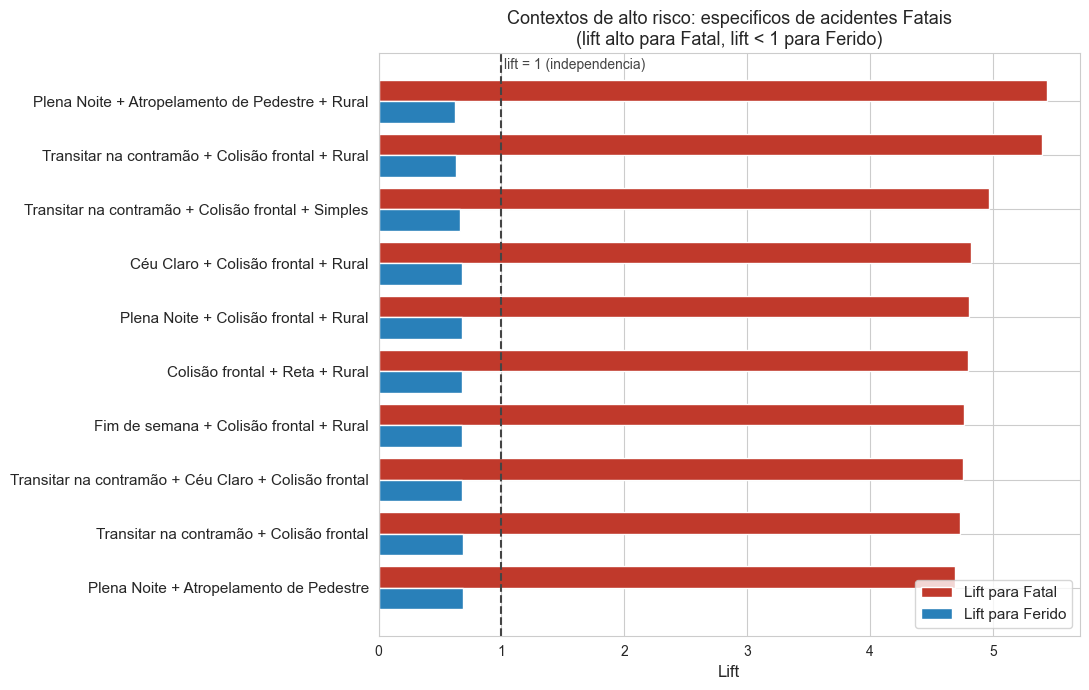

In [7]:
plot_df = comp.sort_values("lift_fatal", ascending=True).reset_index(drop=True)
y = np.arange(len(plot_df))
h = 0.4

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(y + h / 2, plot_df["lift_fatal"], height=h, color=COR_FATAL, label="Lift para Fatal")
ax.barh(y - h / 2, plot_df["lift_ferido"], height=h, color=COR_FERIDO, label="Lift para Ferido")
ax.axvline(1.0, color="#444444", linestyle="--", linewidth=1.5)
ax.text(1.02, len(plot_df) - 0.4, "lift = 1 (independencia)", color="#444444", fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["contexto"], fontsize=11)
ax.set_xlabel("Lift", fontsize=12)
ax.set_title("Contextos de alto risco: especificos de acidentes Fatais\n(lift alto para Fatal, lift < 1 para Ferido)", fontsize=13)
ax.legend(loc="lower right", fontsize=11)
fig.tight_layout()

out_fig = FIGURAS_DIR / "09_comparacao_fatal_ferido.png"
fig.savefig(out_fig, dpi=300, bbox_inches="tight")
shutil.copy(out_fig, POSTER_FIG / "09_comparacao_fatal_ferido.png")
print(f"[OK] Figura salva em {out_fig}")
print(f"[OK] Copiada para {POSTER_FIG / '09_comparacao_fatal_ferido.png'}")
plt.show()

## 5. Tabela comparativa (CSV + LaTeX para o poster)

In [8]:
csv_path = TABELAS_DIR / "comparacao_fatal_ferido.csv"
comp.to_csv(csv_path, index=False, encoding="utf-8")
print(f"[OK] CSV salvo em {csv_path}")


def fmt(x, dec=2):
    return f"{x:.{dec}f}".replace(".", ",")


top5 = comp.head(5)
linhas_tex = [
    r"\begin{tabular}{@{}>{\raggedright\arraybackslash}p{4.2cm}rr@{}}",
    r"\toprule",
    r"\textbf{Contexto} & \textbf{Lift Fatal} & \textbf{Lift Ferido} \\",
    r"\midrule",
]
for _, r in top5.iterrows():
    linhas_tex.append(f"{r['contexto']} & \\textbf{{{fmt(r['lift_fatal'])}}} & {fmt(r['lift_ferido'])} \\\\")
linhas_tex += [r"\bottomrule", r"\end{tabular}"]

tex_path = POSTER_TAB / "comparacao_fatal_ferido.tex"
tex_path.write_text("\n".join(linhas_tex), encoding="utf-8")
print(f"[OK] LaTeX salvo em {tex_path}")
print("\n".join(linhas_tex))

[OK] CSV salvo em D:\Repositórios\mineracao-de-dados-rodovias-federais\outputs\tabelas\comparacao_fatal_ferido.csv
[OK] LaTeX salvo em D:\Repositórios\mineracao-de-dados-rodovias-federais\relatorios\poster\tabelas\comparacao_fatal_ferido.tex
\begin{tabular}{@{}>{\raggedright\arraybackslash}p{4.2cm}rr@{}}
\toprule
\textbf{Contexto} & \textbf{Lift Fatal} & \textbf{Lift Ferido} \\
\midrule
Plena Noite + Atropelamento de Pedestre + Rural & \textbf{5,44} & 0,62 \\
Transitar na contramão + Colisão frontal + Rural & \textbf{5,40} & 0,63 \\
Transitar na contramão + Colisão frontal + Simples & \textbf{4,97} & 0,66 \\
Céu Claro + Colisão frontal + Rural & \textbf{4,82} & 0,68 \\
Plena Noite + Colisão frontal + Rural & \textbf{4,80} & 0,68 \\
\bottomrule
\end{tabular}


## 6. Conclusao

Os contextos de maior lift para **Fatal** (colisao frontal, atropelamento, zona rural, plena noite) apresentam **lift < 1 para Ferido**, ou seja, sao **sub-representados** entre os acidentes nao-fatais. Isso indica que esses padroes nao caracterizam acidentes em geral: eles sao **especificos da fatalidade**. A mineracao independente de Ferido revela contextos distintos (tipicamente urbanos), reforcando a leitura.

> **Associacao != causalidade.** As metricas expressam coocorrencia estatistica.